<a href="https://colab.research.google.com/github/benasphy/Eduera_ML_Projects/blob/main/GMM_Implementation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

In [2]:
#Create a simple 2D dataset
X, y_true = make_blobs(
    n_samples = 300,
    centers = 3,
    cluster_std=0.60,
    random_state=42
)
print(X.shape)

(300, 2)


In [3]:
#Fit GMM
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)

GaussianMixture(n_components=3, random_state=42)

In [4]:
#Predict Cluster Assignments
labels = gmm.predict(X)
print("Cluster labels:", np.unique(labels))


Cluster labels: [0 1 2]


In [5]:
#Get cluster probabilities (soft clustering)
probs = gmm.predict_proba(X)
print(probs[0]) # for one point probability

[3.13845857e-177 1.00000000e+000 1.56850389e-158]


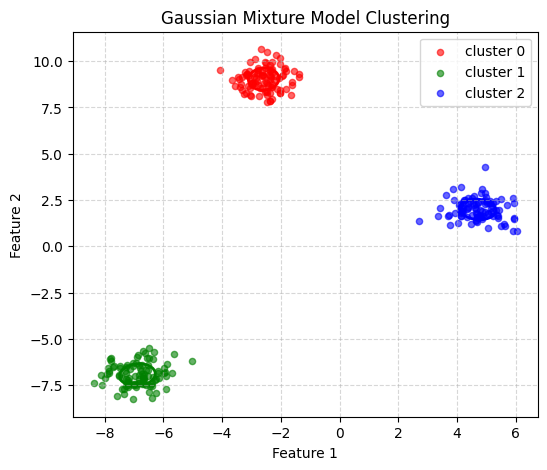

In [6]:
#Plot the clusters with ellipses representing GMM
plt.figure(figsize=(6,5))
colors = ["red", "green", "blue"]

for i, color in enumerate(colors):
  plt.scatter(
      X[labels == i, 0], X[labels==i, 1],
      s = 20, color = color, alpha = 0.6, label = f"cluster {i}"
  )

#Function to draw Gaussian ellipses
def draw_ellipse(mean, cov, ax, color):
  from matplotlib.patches import Ellipse
  import matplotlib.transforms as transforms
  import matplotlib

  #Eigen decomposition of covariance
  vals, vecs = np.linalg.eigh(cov)
  order = vals.argsort()[::-1]
  vals, vecs = vals[order], vecs[:, order]

  theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
  width, height = 2 * np.sqrt(vals)

  ellipse = Ellipse(
      xy=mean, width=width, height=height,
      angle=theta, edgecolor=color, fc="None", lw=2
  )
  ax.add_patch(ellipse)
ax = plt.gca()
for pos, cov, color in zip(gmm.means_, gmm.covariances_, colors):
  draw_ellipse(pos, cov, ax, color)

plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()